# Dynamic Graph Edge Weight Analysis

This notebook analyzes the edge weights (distances or similarities) of the dynamic graphs constructed using the top-k percentile approach. 

**Goal:** Understand the distribution of edge weights across all graphs in the time sequence to design an *adaptive threshold*. This threshold will act as a secondary filter to remove edges that were included by the top-k percentile but are nonetheless "too far" (for distance) or "too dissimilar" (for similarity) due to the changing scale of the graph over time.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Configuration
Select the parameters corresponding to the dynamic graphs you want to analyze.

In [2]:
BASE_DIR = r"c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls"

# --- Configuration ---
ITEM_ID = 26008
METRIC = "cid"  # e.g., 'cid', 'spearman', 'euclidean'
METRIC_TYPE = "distance"  # 'distance' (lower is better) or 'similarity' (higher is better)
WINDOW_SIZE = 15
STEP_SIZE = 1
PREFIX = "" # e.g., "", "star_", "2nddegree_", "2nddegree_star_"
PERCENTILE = 0.5  # e.g., 0.5, 1, 2

# Resolve directory and file paths
dir_label = f"pct{PERCENTILE}"
plot_dir_name = f"{PREFIX}{dir_label}" if PREFIX else dir_label

target_dir = os.path.join(BASE_DIR, str(ITEM_ID), METRIC, str(WINDOW_SIZE), str(STEP_SIZE), plot_dir_name)
pkl_filename = f"{PREFIX}dynamic_graphs_{METRIC}_Window{WINDOW_SIZE}_Step{STEP_SIZE}_{dir_label}.pkl"

if METRIC_TYPE == "distance":
    csv_filename = pkl_filename.replace('.pkl', '_worst_distances.csv')
else:
    csv_filename = pkl_filename.replace('.pkl', '_worst_similarities.csv')

pkl_path = os.path.join(target_dir, pkl_filename)
csv_path = os.path.join(target_dir, csv_filename)

print(f"Target Pickle Path: {pkl_path}")
print(f"Target CSV Path: {csv_path}")

if not os.path.exists(pkl_path):
    print("\nWARNING: Pickle file does not exist. Check your configuration.")

Target Pickle Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\26008\cid\15\1\pct0.5\dynamic_graphs_cid_Window15_Step1_pct0.5.pkl
Target CSV Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\26008\cid\15\1\pct0.5\dynamic_graphs_cid_Window15_Step1_pct0.5_worst_distances.csv


## 2. Load Data

In [3]:
def load_graph_data(pkl_path, csv_path):
    # Load graphs
    with open(pkl_path, 'rb') as f:
        graphs = pickle.load(f)
    
    # Extract all weights
    all_weights = []
    graph_stats = []
    
    for i, g in enumerate(graphs):
        weights = [data.get('weight', 0) for u, v, data in g.edges(data=True)]
        all_weights.extend(weights)
        
        if len(weights) > 0:
            stats = {
                'window_idx': i,
                'window_start': g.graph.get('start_date'),
                'num_nodes': g.number_of_nodes(),
                'num_edges': g.number_of_edges(),
                'mean': np.mean(weights),
                'median': np.median(weights),
                'std': np.std(weights),
                'min': np.min(weights),
                'max': np.max(weights),
            }
        else:
             stats = {
                'window_idx': i,
                'window_start': g.graph.get('start_date'),
                'num_nodes': g.number_of_nodes(), 'num_edges': 0,
                'mean': np.nan, 'median': np.nan, 'std': np.nan, 'min': np.nan, 'max': np.nan
            }
        graph_stats.append(stats)
    
    df_stats = pd.DataFrame(graph_stats)
    if 'window_start' in df_stats.columns:
        df_stats['window_start'] = pd.to_datetime(df_stats['window_start'])
    
    # Load Worst CSV if exists
    df_worst = None
    if os.path.exists(csv_path):
        df_worst = pd.read_csv(csv_path)
    
    return graphs, all_weights, df_stats, df_worst

graphs, all_weights, df_stats, df_worst = load_graph_data(pkl_path, csv_path)
print(f"Loaded {len(graphs)} graphs.")
print(f"Total edges across all time steps: {len(all_weights)}")
df_stats.head()

Loaded 595 graphs.
Total edges across all time steps: 12016


,window_idx,window_start,num_nodes,num_edges,mean,median,std,min,max
0,0,2021-01-23,8,17,52.474430,0.014210,68.581794,0.005402,190.312759
1,1,2021-01-24,8,16,55.941270,0.014509,69.314122,0.005783,183.042526
2,2,2021-01-25,8,17,51.907017,0.014408,68.523766,0.005305,192.120346
3,3,2021-01-26,8,17,50.531785,0.013617,69.394121,0.005520,202.327118
4,4,2021-01-27,8,17,50.574107,0.014090,70.266956,0.005355,203.582153


In [8]:
# Get the top 10 and bottom 10 weights (distances/similarities) from all graphs combined, along with node info
all_edges_info = []
for g in graphs:
    window_start = g.graph.get('start_date')
    for u, v, data in g.edges(data=True):
        w = data.get('weight', 0)
        all_edges_info.append((w, u, v, window_start))

if all_edges_info:
    sorted_edges = sorted(all_edges_info, key=lambda x: x[0])
    bottom_10_edges = sorted_edges[:10]
    top_10_edges = sorted_edges[-10:]
    top_10_edges.reverse() # sort descending for the top 10

    print(f"Top 10 {METRIC_TYPE}s from all graphs:")
    for i, (w, u, v, date) in enumerate(top_10_edges, 1):
        print(f"{i}. Weight: {w:.6f} | Nodes: {u} <-> {v} | Date: {date}")
        
    print(f"\nBottom 10 {METRIC_TYPE}s from all graphs:")
    for i, (w, u, v, date) in enumerate(bottom_10_edges, 1):
        print(f"{i}. Weight: {w:.6f} | Nodes: {u} <-> {v} | Date: {date}")
else:
    print("No weights found.")

Top 10 distances from all graphs:
1. Weight: 2778.683838 | Nodes: 26008 <-> 930471 | Date: 2021-12-11
2. Weight: 2760.429443 | Nodes: 26008 <-> 545602 | Date: 2021-12-11
3. Weight: 2708.276611 | Nodes: 26008 <-> 26862 | Date: 2021-12-12
4. Weight: 2665.378906 | Nodes: 26008 <-> 8514 | Date: 2021-12-12
5. Weight: 2626.810303 | Nodes: 26008 <-> 213631 | Date: 2021-12-13
6. Weight: 2611.246582 | Nodes: 26008 <-> 8514 | Date: 2021-12-13
7. Weight: 2611.124756 | Nodes: 26008 <-> 8514 | Date: 2021-12-11
8. Weight: 2591.035400 | Nodes: 26008 <-> 13544 | Date: 2021-12-13
9. Weight: 2572.523193 | Nodes: 26008 <-> 13544 | Date: 2021-12-11
10. Weight: 2565.295410 | Nodes: 26008 <-> 213631 | Date: 2021-12-11

Bottom 10 distances from all graphs:
1. Weight: 0.000406 | Nodes: 8514 <-> 110187 | Date: 2021-12-12
2. Weight: 0.000410 | Nodes: 26862 <-> 110187 | Date: 2021-12-12
3. Weight: 0.000429 | Nodes: 18568 <-> 26220 | Date: 2021-12-10
4. Weight: 0.000434 | Nodes: 8514 <-> 110187 | Date: 2021-12-13

In [4]:
import matplotlib.dates as mdates

percentiles_to_test = [0.5, 1, 2]
results_by_percentile = {}

def calculate_thresholds(weights, metric_type, k_std=2.0, p_cutoff=95):
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    median_w = np.median(weights)
    mad_w = np.median(np.abs(weights - median_w))
    
    thresholds = {}
    if metric_type == "distance":
        thresholds['Mean + k*Std'] = mean_w + k_std * std_w
        thresholds['Median + k*MAD'] = median_w + (k_std * 1.4826) * mad_w
        thresholds[f'Percentile {p_cutoff}'] = np.percentile(weights, p_cutoff)
    else:
        thresholds['Mean - k*Std'] = mean_w - k_std * std_w
        thresholds['Median - k*MAD'] = median_w - (k_std * 1.4826) * mad_w
        thresholds[f'Percentile {100-p_cutoff}'] = np.percentile(weights, 100 - p_cutoff)
        
    return thresholds

for pct in percentiles_to_test:
    # 1. Update paths for this percentile
    dir_label = f"pct{pct}"
    plot_dir_name = f"{PREFIX}{dir_label}" if PREFIX else dir_label
    target_dir = os.path.join(BASE_DIR, str(ITEM_ID), METRIC, str(WINDOW_SIZE), str(STEP_SIZE), plot_dir_name)
    pkl_filename = f"{PREFIX}dynamic_graphs_{METRIC}_Window{WINDOW_SIZE}_Step{STEP_SIZE}_{dir_label}.pkl"
    
    if METRIC_TYPE == "distance":
        csv_filename = pkl_filename.replace('.pkl', '_worst_distances.csv')
    else:
        csv_filename = pkl_filename.replace('.pkl', '_worst_similarities.csv')
        
    pkl_path = os.path.join(target_dir, pkl_filename)
    csv_path = os.path.join(target_dir, csv_filename)
    
    if not os.path.exists(pkl_path):
        print(f"Skipping {pct}%: File not found ({pkl_path})")
        continue

    # 2. Load data
    graphs, all_weights, df_stats, df_worst = load_graph_data(pkl_path, csv_path)
    
    # 3. Calculate candidate thresholds
    candidate_thresholds = calculate_thresholds(all_weights, METRIC_TYPE, k_std=1.5, p_cutoff=90)
    
    # 4. Filter graphs and compute worst metrics for EACH threshold strategy
    strategy_results = {}
    for strat_name, thr_val in candidate_thresholds.items():
        filtered_stats = []
        total_edges_before = 0
        total_edges_after = 0
        
        for i, g in enumerate(graphs):
            g_filtered = g.copy()
            total_edges_before += g.number_of_edges()
            
            if METRIC_TYPE == "distance":
                edges_to_remove = [(u, v) for u, v, data in g.edges(data=True) if data.get('weight', 0) > thr_val]
            else:
                edges_to_remove = [(u, v) for u, v, data in g.edges(data=True) if data.get('weight', 0) < thr_val]
            
            g_filtered.remove_edges_from(edges_to_remove)
            total_edges_after += g_filtered.number_of_edges()
            
            weights = [data.get('weight', 0) for u, v, data in g_filtered.edges(data=True)]
            start_date = g_filtered.graph.get('start_date')
            
            if len(weights) > 0:
                worst = np.max(weights) if METRIC_TYPE == 'distance' else np.min(weights)
            else:
                worst = np.nan
            filtered_stats.append({'window_start': start_date, 'worst': worst})
            
        df_filtered = pd.DataFrame(filtered_stats)
        df_filtered['window_start'] = pd.to_datetime(df_filtered['window_start'])
        edges_removed = total_edges_before - total_edges_after
        perc_removed = (edges_removed / total_edges_before * 100) if total_edges_before > 0 else 0
        
        strategy_results[strat_name] = {
            'threshold_val': thr_val,
            'df_filtered': df_filtered,
            'edges_removed': edges_removed,
            'perc_removed': perc_removed
        }
    
    results_by_percentile[pct] = {
        'all_weights': all_weights,
        'strategies': strategy_results,
        'df_stats_before': df_stats,
        'df_worst_before': df_worst
    }
    print(f"Computed processing for percentile {pct}%")

Computed processing for percentile 0.5%
Computed processing for percentile 1%
Computed processing for percentile 2%


### Plot Worst Distances Before Filtering

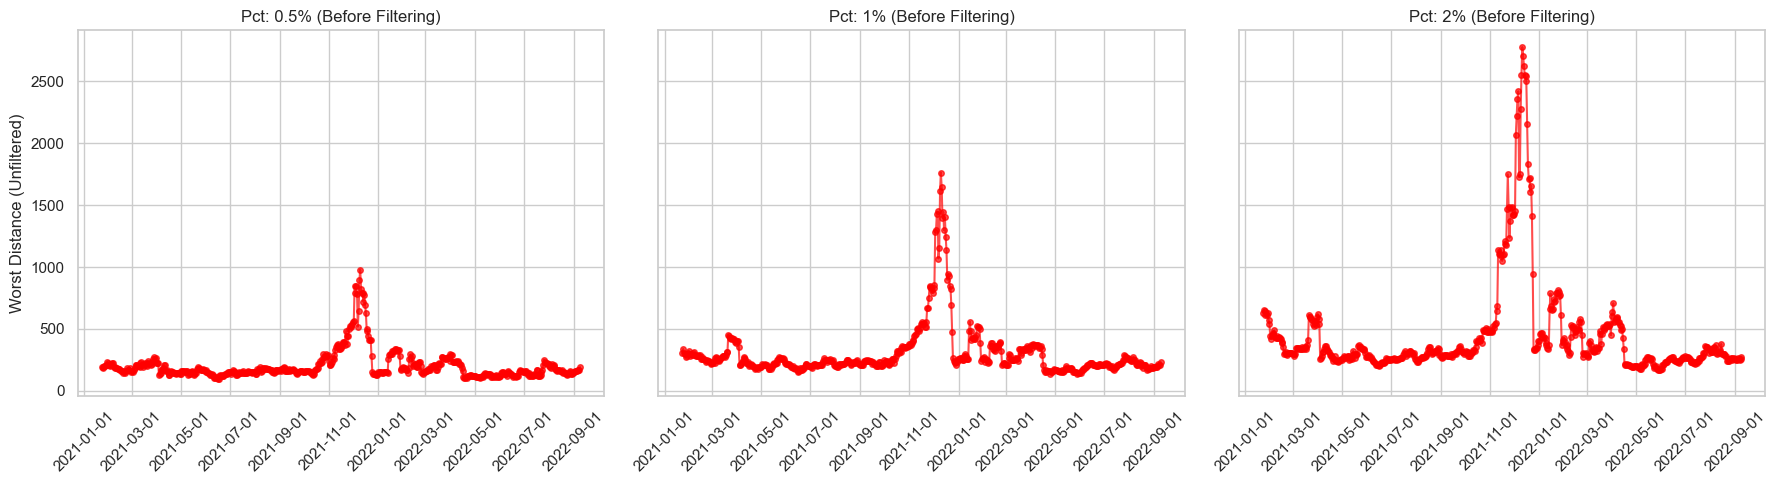

In [5]:
num_pct = len(results_by_percentile.keys())
if num_pct > 0:
    fig, axes = plt.subplots(1, num_pct, figsize=(6 * num_pct, 5), sharex=True, sharey=True)
    if num_pct == 1:
        axes = [axes]
    
    for i, (pct, result_dict) in enumerate(results_by_percentile.items()):
        ax = axes[i]
        df_stats_before = result_dict['df_stats_before']
        # If METRIC_TYPE is "distance", worst is "max", else "min"
        worst_col = 'max' if METRIC_TYPE == 'distance' else 'min'
        worst_series_before = df_stats_before[worst_col]
        
        ax.plot(df_stats_before['window_start'], worst_series_before, marker='o', markersize=4, linestyle='-', alpha=0.7, color='red')
        
        ax.set_title(f"Pct: {pct}% (Before Filtering)", fontsize=12)
        if i == 0:
            ax.set_ylabel(f"Worst {METRIC_TYPE.capitalize()} (Unfiltered)")
            
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")

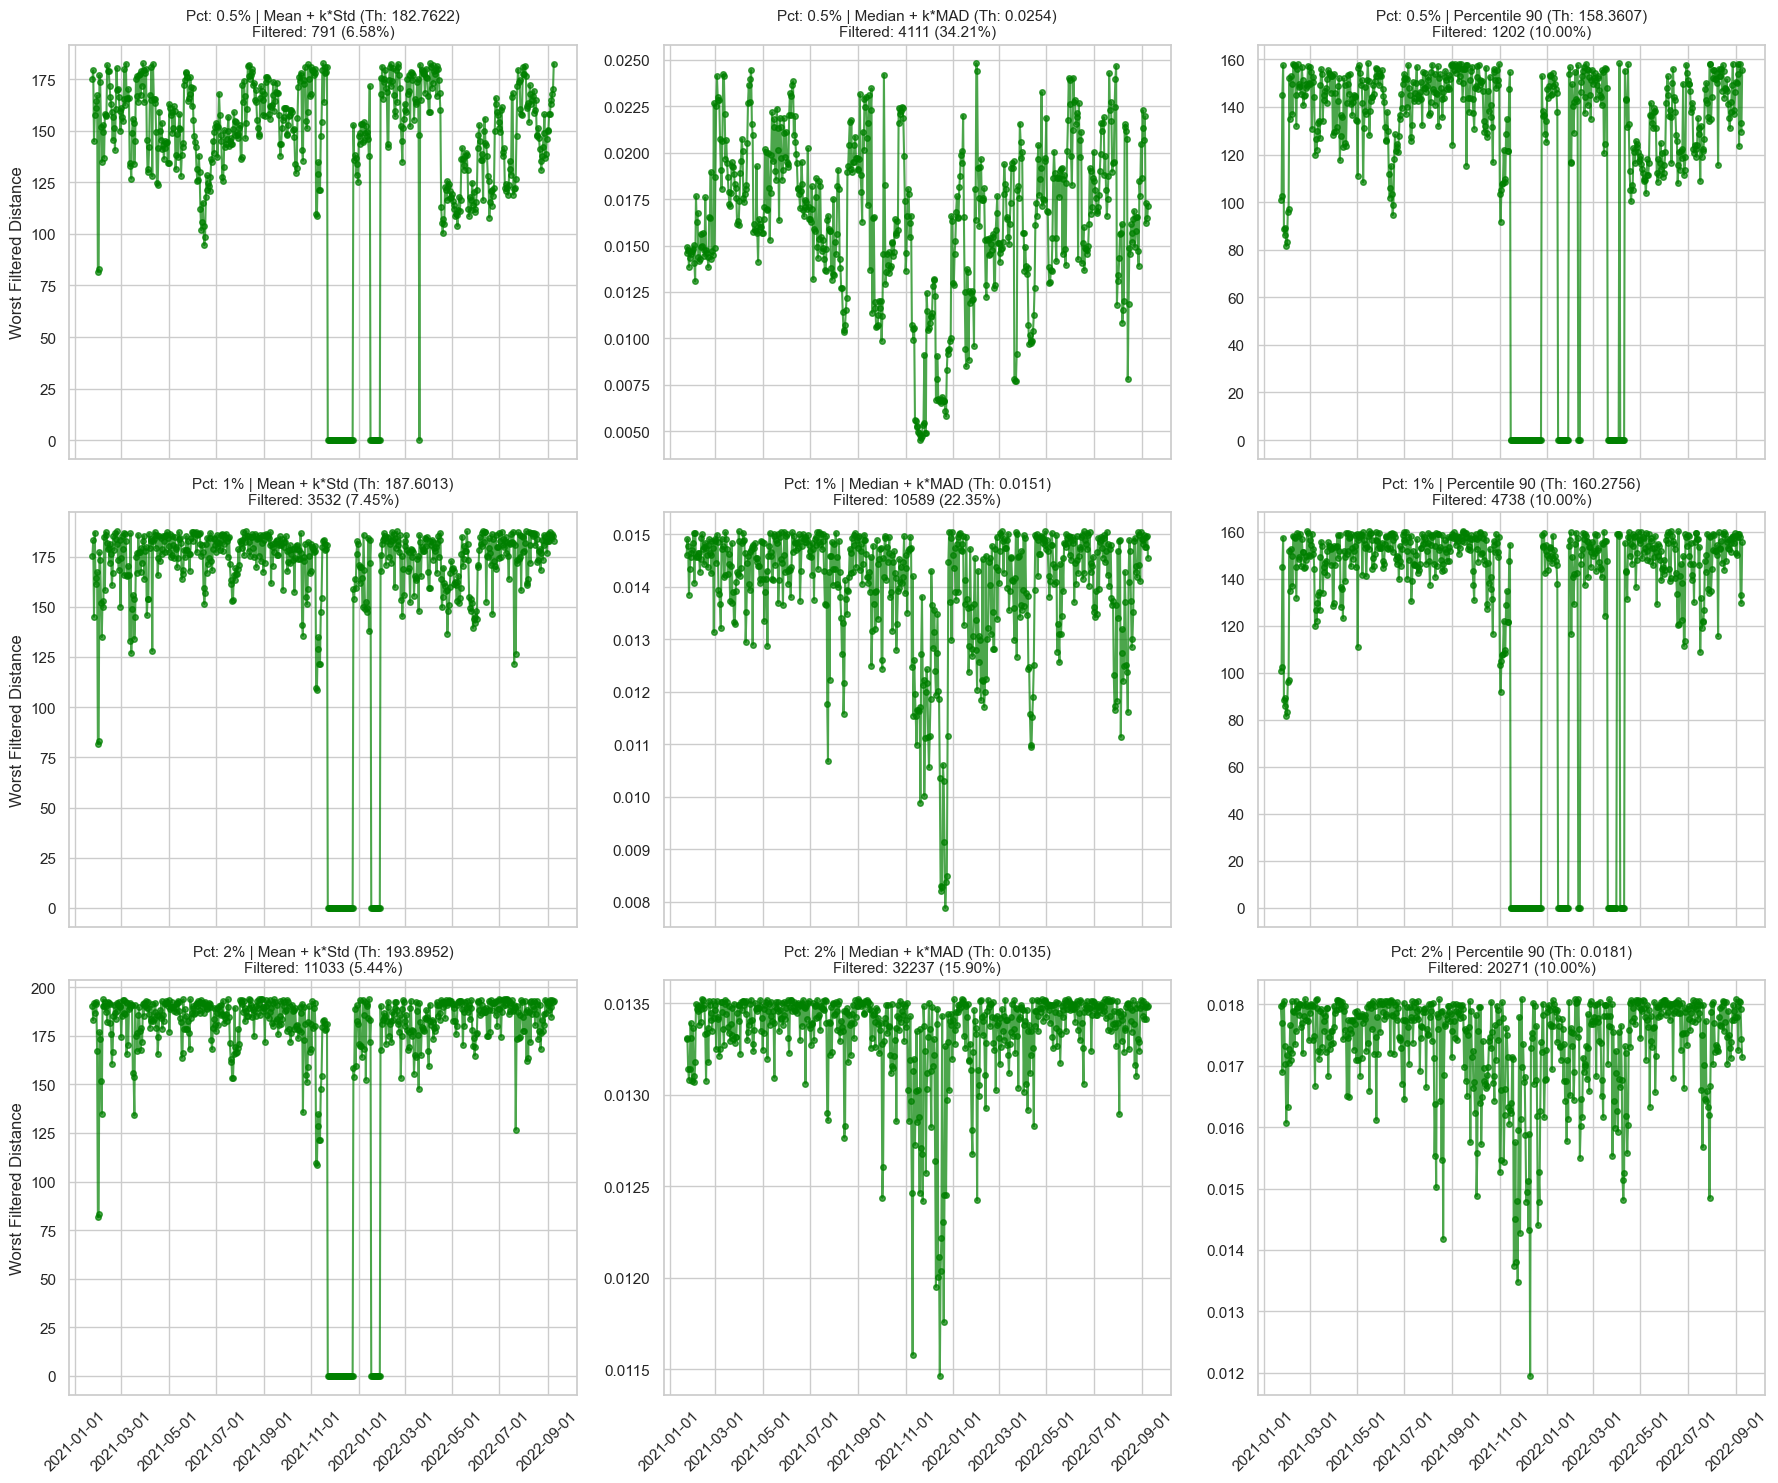

In [6]:
# Plotting Grid 
# Rows: Percentiles
# Cols: Threshold Formulas
num_pct = len(results_by_percentile.keys())
formulas = list(list(results_by_percentile.values())[0]['strategies'].keys()) if num_pct > 0 else []
num_fw = len(formulas)

if num_pct > 0 and num_fw > 0:
    fig, axes = plt.subplots(num_pct, num_fw, figsize=(6 * num_fw, 5 * num_pct), sharex=True, sharey=False)
    
    # Handle single row/col cases
    if num_pct == 1:
        axes = [axes]
    if num_fw == 1:
        axes = [[ax] for ax_row in axes for ax in ax_row]

    for i, (pct, result_dict) in enumerate(results_by_percentile.items()):
        strats = result_dict['strategies']
        
        for j, (strat_name, strat_data) in enumerate(strats.items()):
            ax = axes[i][j]
            df_filtered = strat_data['df_filtered']
            thr_val = strat_data['threshold_val']
            edges_removed = strat_data.get('edges_removed', 0)
            perc_removed = strat_data.get('perc_removed', 0)
            
            worst_series = df_filtered['worst']
            
            # Line plot over time
            ax.plot(df_filtered['window_start'], worst_series, marker='o', markersize=4, linestyle='-', alpha=0.7, color='green')
            
            ax.set_title(f"Pct: {pct}% | {strat_name} (Th: {thr_val:.4f})\nFiltered: {edges_removed} ({perc_removed:.2f}%)", fontsize=11)
            if j == 0:
                ax.set_ylabel(f"Worst Filtered {METRIC_TYPE.capitalize()}")
                
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            # rotate tick labels for all plots
            for tick in ax.get_xticklabels():
                tick.set_rotation(45)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")